In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

anlewe1_docana_project_data_path = kagglehub.dataset_download('anlewe1/docana-project-data')
print('Data source import complete.')


Data source import complete.


# Part I: Project Idea and Research Question

Previously, we conducted a TF-IDF analysis on several gaming-related subreddits to identify key terms and examined the sentiment of the sentences in which these terms appeared. This exploratory work suggested a connection between team play and emotional responses in gamer discussions. Building on this, and supported by existing research, we focus here on how anger expressions relate to game type, subreddit, and genre groups.

The literature highlights that playing with weak teammates elicits anger (Greitemeyer & Mügge, 2014), situating this project within the broader framework of the General Learning Model (GLM). The GLM posits that video game content strongly influences social behavior—violent games tend to increase aggression and reduce prosocial behavior, while prosocial games promote the opposite effects. These effects are bidirectional and can manifest both immediately and over long-term repeated exposure.

Meta-analyses (e.g., Anderson et al., 2010) have confirmed that violent video games increase aggressive thoughts, emotions, and behaviors while decreasing empathy and helping tendencies. Since cooperative behavior and empathy counteract aggression (Eron & Huesmann, 1984), it is plausible that playing violent games cooperatively might reduce aggressive responses.

Motivated by these findings and the theoretical framework, this project investigates whether cooperative gameplay moderates anger expressions in online gaming discourse. Specifically, we examine if cooperative modes attenuate anger compared to non-cooperative modes across different game types and subreddit contexts.

**Research Questions:**
1. Does team play increase anger level expressed in subreddit gaming communities?
2. Does cooperative gameplay reduce anger expression in gaming communities?

**Hypotheses:**

- Hypothesis 1: Increased team play—i.e., games involving more players or multiplayer modes—is associated with higher anger expression.
This hypothesis is inspired by evidence that playing with weak or frustrating teammates often elicits anger, especially in competitive multiplayer environments where coordination and performance matter. As the number of players increases, the potential for conflict, frustration, and thus anger may rise, reflected in the emotional content of online comments.
- Hypothesis 2: Cooperative gameplay moderates anger expression, such that playing cooperatively reduces anger, particularly in genres or subreddit communities associated with violent or competitive content.
Based on the General Learning Model (GLM) and empirical findings on prosocial game effects, cooperative play may buffer aggressive responses by fostering empathy and social bonding, thereby lowering anger expression despite violent or competitive game contexts.
Together, these hypotheses aim to clarify the complex relationship between game mode (team size and cooperation), game content, and emotional reactions as reflected in gamer discourse online.

# 0. Setup

In [4]:
!pip install beautifulsoup4 --quiet
!pip install rapidfuzz --quiet
!pip install python-Levenshtein --quiet
!pip install transformers --quiet
!pip install torch --quiet
!pip list | grep sentiment_labeller --quiet

In [5]:
from datasets import load_dataset
from datasets import Dataset
import pandas as pd
import numpy as np
import json
import csv
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

import requests
from bs4 import BeautifulSoup
import time
import requests
from datetime import datetime
from rapidfuzz import fuzz
#from kaggle_secrets import UserSecretsClient # not for colab version

import transformers
from transformers import pipeline
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0))

import os
import gc

import warnings
warnings.filterwarnings('ignore')

CUDA available: True
Device name: Tesla T4


In [6]:
torch.cuda.empty_cache()
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Jul  2 13:42:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Part II: Data Retrieval

## 2.1 Import Dataset
the tldr-17 subreddit dataset from Huggingface

In [ ]:
# Load hgf dataset
ds = load_dataset("webis/tldr-17", split="train")

In [ ]:
df = ds.to_pandas()
print(df.shape)
df.head()

## 2.2 Link Table Retrieval: subreddit names - game names

Aquire full game names per gaming subreddit. For this, I scraped another table from reddit, which matches the names of /r/subreddits with the actual corresponding game names.
The code is provided as a markdown chunk below, since the datasest once retrieved does not have to be called upon again every time running the code. The dataset is uploaded to '/kaggle/input/subreddit-gaming-names/reddit_gaming_games_and_series.csv'. However, though this ran locally, the request is blocked when run in the browser.
Upon merging this newly retreived table onto the tldr-17 dataset, we filter for only subreddits that are about a particular game.

In [ ]:
'''url = "https://www.reddit.com/r/gaming/wiki/list-sorted-by-subscribers/"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/114.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
print(response.status_code)

if response.status_code == 200:
    soup = BeautifulSoup(response.content, 'html.parser')
    header = soup.find('h1', id='wiki_games_and_series')

    if header:
        table = header.find_next('table')
        if table:
            # Extract headers
            table_headers = [th.get_text(strip=True) for th in table.find_all('th')]

            # Extract rows
            rows = []
            for tr in table.find_all('tr')[1:]:
                cells = [td.get_text(strip=True) for td in tr.find_all('td')]
                if cells:  # Only add non-empty rows
                    rows.append(cells)

            # Remove leading '/r/' from Link column if it exists
            for row in rows:
                if len(row) > 1 and row[1].startswith('/r/'):
                    row[1] = row[1][3:]

            # Save to CSV
            with open('reddit_gaming_games_and_series.csv', 'w', newline='', encoding='utf-8') as f:
                writer = csv.writer(f)
                if table_headers:
                    writer.writerow(table_headers)
                writer.writerows(rows)

            print("Data saved to reddit_gaming_games_and_series.csv")
        else:
            print("Table not found")
    else:
        print("Header not found")
else:
    print(f"Failed to fetch page: {response.status_code}")'''

In [ ]:
# I've uploaded the resulting df to kaggle and retrieve it from there
csv_path = os.path.join(anlewe1_docana_project_data_path, 'reddit_gaming_games_and_series.csv')
df_expand = pd.read_csv(csv_path)

print(df_expand.shape)
print(df_expand.head())

## 2.3 Filter tldr-17 for game subreddits

In [ ]:
# Normalize subreddit and Link columns to lowercase
df['subreddit'] = df['subreddit'].str.lower()
df_expand['Link'] = df_expand['Link'].str.lower()

# Merge on subreddit == Link
df_filtered = pd.merge(
    df,
    df_expand[['Name', 'Link']],
    left_on='subreddit',
    right_on='Link',
    how='inner'
)

# Drop the redundant 'Link' column
df_filtered = df_filtered.drop(columns=['Link'])

# Inspect the result
print(df_filtered.shape)
df_filtered.head()

In [ ]:
df_filtered['subreddit'].value_counts()

In [ ]:
# Get counts per subreddit
counts = df_filtered['subreddit'].value_counts()

# Filter for subreddits with >= 100 posts
threshold = 100
valid_subreddits = counts[counts >= threshold].index

# Filter the dataframe
df_active = df_filtered[df_filtered['subreddit'].isin(valid_subreddits)]



# Manual fixes in df_active before matching
fixes = {
    'hearthstone: heroes of warcraft': 'Hearthstone',
    'borderlands (self)': 'Borderlands',
}

# Make sure you work on the original df, or a copy explicitly:
df_active = df_active.copy()

# Use .loc with a mask for replacement:
for wrong_name, correct_name in fixes.items():
    mask = df_active['Name'].str.lower() == wrong_name
    df_active.loc[mask, 'Name'] = correct_name

print(df_active.shape)
#df_active.to_csv('df_active_games.csv', index=False) # relatively large

In [ ]:
unique_subreddits = df_active['subreddit'].unique()
#games_subreddits = df_games['subreddit'].str.lower().unique()

#all_in_active = set(games_subreddits).issubset(set(unique_subreddits))
#print(f"All game subreddits in filtered set? {all_in_active}")

#missing = set(games_subreddits) - set(unique_subreddits)
#print(f"Missing subreddits: {missing}")

print(f"\nTotal unique subreddits: {len(unique_subreddits)}\n")

# Create a mapping from subreddit to Name (lowercase to match)
sub_to_name = dict(zip(df_active['subreddit'].str.lower(), df_active['Name']))

for i, sub in enumerate(unique_subreddits, 1):
    name = sub_to_name.get(sub, "N/A")  # fallback if no match
    print(f"{i}. {sub} — {name}")

## 2.4 Sample from game subreddits

To create a balanced and manageable dataset, we performed stratified sampling by subreddit. Specifically, we randomly sampled up to 500 comments from each subreddit. For subreddits with fewer than 500 comments, we included all available comments. This approach helps maintain representativeness across subreddits while reducing the dataset size for more efficient processing, especially sentiment analysis.

The sampling used a fixed random seed (`random_state=42`) to guarantee reproducibility. After sampling, the resulting dataset is saved as a CSV file.


In [ ]:
# Number of samples per subreddit
sample_size = 500

# Sample 500 comments per subreddit (or fewer if subreddit has fewer)
df_sampled = (
    df_active.groupby('subreddit', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), sample_size), random_state=42))
    .reset_index(drop=True)
)
print(f"Sampled {len(df_sampled)} comments total from {df_sampled['subreddit'].nunique()} subreddits.")

print(df_sampled.shape)
df_sampled.to_csv('df_sampled_games.csv', index=False)
from google.colab import files
files.download('df_sampled_games.csv')

## 2.5 Get metadata from IGDB database API - ggf. retrieve again, including online status

We now substantially expand our game metadata beyond basic information, creating a foundation for analysing what drives sentiment in gaming subreddits:
**Core Game Metadata**

*Genres:* Multi-category classification from both RAWG.io and IGDB systems
*Similar Games:* Network of related games (by game ID) for similarity analysis
Game Modes: Single-player, multiplayer, co-op capabilities
Release Information: First release date for temporal analysis
Game Descriptions: Detailed summaries for text mining

Advanced Metadata (New)

Rating Systems: Multiple rating metrics (aggregated_rating, total_rating, player ratings)
Keywords: Specific game mechanics, features, and descriptors
Themes: Narrative and aesthetic themes (horror, fantasy, sci-fi, etc.)
Platforms: Gaming system availability and exclusivity patterns
Player Perspectives: First-person, third-person, isometric viewpoints
Multiplayer Modes: Detailed co-op features, online/offline capabilities, max players

Game Name Matching Methodology
Fuzzy String Matching Process
We employ token-based fuzzy matching using the Levenshtein distance algorithm via fuzzywuzzy.fuzz.token_sort_ratio():

Query Process: Search IGDB API with game name (up to 20 candidates returned)
Preprocessing: Both input and candidate names are:

Converted to lowercase
Tokenized and sorted alphabetically
Special characters normalized


Similarity Scoring: Token sort ratio calculates similarity based on:

Character-level edit distance
Token order independence ("Call of Duty: Modern Warfare" matches "Modern Warfare: Call of Duty")
Partial string matching for abbreviations and variations


Best Match Selection: Highest scoring candidate above threshold is selected

Similarity Measure
The token sort ratio ranges from 0-100, representing percentage similarity:

90-100: Excellent match (exact or near-exact)
80-89: Good match (minor variations, abbreviations)
70-79: Fair match (significant but recognizable differences)
<70: Poor match (requires manual review)

In [ ]:
# Dataframe for matching using unique subreddits and their mapped names
data_for_matching = []
for sub in unique_subreddits:
    name = sub_to_name.get(sub, "N/A")  # fallback if no mapping found
    data_for_matching.append({'subreddit': sub, 'Name': name})

df_for_matching = pd.DataFrame(data_for_matching)

In [ ]:
# API CONFIG

# For colab version:
#from google.colab import userdata
#CLIENT_SECRET = userdata.get('"IGDB"')
#CLIENT_ID = 'p1m7pkjtxxkc3hbburs32od1fzfcxk'

# previously in kaggle
#user_secrets = UserSecretsClient()
#CLIENT_SECRET = user_secrets.get_secret("IGDB")
#CLIENT_ID = 'p1m7pkjtxxkc3hbburs32od1fzfcxk'

In [ ]:
# ====== Twitch OAuth - get access token (run once) ======

"""

auth_url = 'https://id.twitch.tv/oauth2/token'
auth_params = {
    'client_id': CLIENT_ID,
    'client_secret': CLIENT_SECRET,
    'grant_type': 'client_credentials'
}
auth_response = requests.post(auth_url, params=auth_params)
auth_response.raise_for_status()
ACCESS_TOKEN = auth_response.json()['access_token']
HEADERS = {
    'Client-ID': CLIENT_ID,
    'Authorization': f'Bearer {ACCESS_TOKEN}',
}
BASE_URL = 'https://api.igdb.com/v4/{}'

def make_api_request(endpoint, query):
    url = BASE_URL.format(endpoint)
    try:
        response = requests.post(url, headers=HEADERS, data=query)
        response.raise_for_status()
        time.sleep(0.25)  # rate limit buffer
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"API request error at {endpoint}: {e}")
        return []

def search_games_by_name(name, limit=20):
    # Enhanced query with additional fields
    query = f'''
    search "{name}";
    fields id,name,summary,first_release_date,genres,similar_games,game_modes,
           aggregated_rating,game_type,keywords,multiplayer_modes,platforms,
           player_perspectives,rating,themes,total_rating;
    limit {limit};
    '''
    return make_api_request('games', query)

def get_genres(genre_ids):
    if not genre_ids:
        return []
    query = f'fields id,name,slug; where id=({",".join(map(str, genre_ids))});'
    return make_api_request('genres', query)

def get_game_modes(game_mode_ids):
    if not game_mode_ids:
        return []
    query = f'fields id,name,slug; where id=({",".join(map(str, game_mode_ids))});'
    return make_api_request('game_modes', query)

def get_keywords(keyword_ids):
    if not keyword_ids:
        return []
    query = f'fields id,name,slug; where id=({",".join(map(str, keyword_ids))});'
    return make_api_request('keywords', query)

def get_multiplayer_modes(multiplayer_mode_ids):
    if not multiplayer_mode_ids:
        return []
    query = f'fields id,campaigncoop,dropin,lancoop,offlinecoop,offlinemax,onlinecoop,onlinemax,platform,splitscreen; where id=({",".join(map(str, multiplayer_mode_ids))});'
    return make_api_request('multiplayer_modes', query)

def get_platforms(platform_ids):
    if not platform_ids:
        return []
    query = f'fields id,name,slug; where id=({",".join(map(str, platform_ids))});'
    return make_api_request('platforms', query)

def get_player_perspectives(perspective_ids):
    if not perspective_ids:
        return []
    query = f'fields id,name,slug; where id=({",".join(map(str, perspective_ids))});'
    return make_api_request('player_perspectives', query)

def get_themes(theme_ids):
    if not theme_ids:
        return []
    query = f'fields id,name,slug; where id=({",".join(map(str, theme_ids))});'
    return make_api_request('themes', query)

def unix_to_date(unix_timestamp):
    if unix_timestamp:
        return datetime.fromtimestamp(unix_timestamp).strftime('%Y-%m-%d')
    return None

def best_match(game_name, candidates):
    # Use fuzzy matching to pick the best candidate game name from IGDB results
    best_score = 0
    best_game = None
    for game in candidates:
        candidate_name = game.get('name', '')
        score = fuzz.token_sort_ratio(game_name.lower(), candidate_name.lower())
        if score > best_score:
            best_score = score
            best_game = game
    return best_game, best_score

def fetch_metadata_for_games(game_list):
    # Batch collect all metadata ids to minimize API calls
    all_genres = set()
    all_game_modes = set()
    all_keywords = set()
    all_multiplayer_modes = set()
    all_platforms = set()
    all_player_perspectives = set()
    all_themes = set()

    for g in game_list:
        all_genres.update(g.get('genres', []))
        all_game_modes.update(g.get('game_modes', []))
        all_keywords.update(g.get('keywords', []))
        all_multiplayer_modes.update(g.get('multiplayer_modes', []))
        all_platforms.update(g.get('platforms', []))
        all_player_perspectives.update(g.get('player_perspectives', []))
        all_themes.update(g.get('themes', []))

    # Fetch all metadata
    genres = get_genres(list(all_genres))
    game_modes = get_game_modes(list(all_game_modes))
    keywords = get_keywords(list(all_keywords))
    multiplayer_modes = get_multiplayer_modes(list(all_multiplayer_modes))
    platforms = get_platforms(list(all_platforms))
    player_perspectives = get_player_perspectives(list(all_player_perspectives))
    themes = get_themes(list(all_themes))

    # Create dictionaries for lookups
    genres_dict = {g['id']: g.get('slug', g.get('name', '')) for g in genres}
    game_modes_dict = {gm['id']: gm.get('slug', gm.get('name', '')) for gm in game_modes}
    keywords_dict = {k['id']: k.get('slug', k.get('name', '')) for k in keywords}
    platforms_dict = {p['id']: p.get('slug', p.get('name', '')) for p in platforms}
    player_perspectives_dict = {pp['id']: pp.get('slug', pp.get('name', '')) for pp in player_perspectives}
    themes_dict = {t['id']: t.get('slug', t.get('name', '')) for t in themes}

    # Process multiplayer modes differently as they have complex structure
    multiplayer_modes_dict = {}
    for mm in multiplayer_modes:
        mm_id = mm['id']
        mm_features = []
        if mm.get('campaigncoop'): mm_features.append('campaign_coop')
        if mm.get('dropin'): mm_features.append('drop_in')
        if mm.get('lancoop'): mm_features.append('lan_coop')
        if mm.get('offlinecoop'): mm_features.append('offline_coop')
        if mm.get('onlinecoop'): mm_features.append('online_coop')
        if mm.get('splitscreen'): mm_features.append('splitscreen')

        mm_info = '; '.join(mm_features)
        if mm.get('offlinemax'):
            mm_info += f" (offline_max: {mm['offlinemax']})"
        if mm.get('onlinemax'):
            mm_info += f" (online_max: {mm['onlinemax']})"

        multiplayer_modes_dict[mm_id] = mm_info

    return (genres_dict, game_modes_dict, keywords_dict, multiplayer_modes_dict,
            platforms_dict, player_perspectives_dict, themes_dict)

def process_df_active(df_active):
    # Assume df_active has columns ['subreddit', 'Name']
    results = []
    # Keep track of all matched games for metadata bulk retrieval
    matched_games = []

    print(f"Processing {len(df_active)} games...")

    for idx, row in df_active.iterrows():
        subreddit = row['subreddit'].lower()
        game_name = row['Name']

        if not isinstance(game_name, str) or not game_name.strip():
            print(f"Skipping empty name for subreddit {subreddit}")
            continue

        candidates = search_games_by_name(game_name)
        if not candidates:
            print(f"No candidates found in IGDB for {game_name}")
            continue

        best_game, score = best_match(game_name, candidates)
        if not best_game:
            print(f"No good match found for {game_name}")
            continue

        matched_games.append(best_game)

        results.append({
            'subreddit': subreddit,
            'input_name': game_name,
            'matched_game_id': best_game['id'],
            'matched_game_name': best_game.get('name', ''),
            'match_score': score,
            'summary': best_game.get('summary', ''),
            'first_release_date': unix_to_date(best_game.get('first_release_date')),

            # New fields
            'aggregated_rating': best_game.get('aggregated_rating'),
            'game_type': best_game.get('game_type'),
            'rating': best_game.get('rating'),
            'total_rating': best_game.get('total_rating'),

            # ID lists for metadata lookup
            'genres_ids': best_game.get('genres', []),
            'game_modes_ids': best_game.get('game_modes', []),
            'keywords_ids': best_game.get('keywords', []),
            'multiplayer_modes_ids': best_game.get('multiplayer_modes', []),
            'platforms_ids': best_game.get('platforms', []),
            'player_perspectives_ids': best_game.get('player_perspectives', []),
            'themes_ids': best_game.get('themes', []),
            'similar_games': best_game.get('similar_games', []),
        })

        print(f"Matched '{game_name}' -> '{best_game.get('name')}' with score {score}")

    # Remove duplicate games to avoid redundant metadata calls
    unique_games = {g['id']: g for g in matched_games}.values()
    (genres_dict, game_modes_dict, keywords_dict, multiplayer_modes_dict,
     platforms_dict, player_perspectives_dict, themes_dict) = fetch_metadata_for_games(unique_games)

    # Add human-readable metadata
    for r in results:
        r['genres'] = '; '.join(genres_dict.get(gid, '') for gid in r['genres_ids'] if gid in genres_dict)
        r['game_modes'] = '; '.join(game_modes_dict.get(gmid, '') for gmid in r['game_modes_ids'] if gmid in game_modes_dict)
        r['keywords'] = '; '.join(keywords_dict.get(kid, '') for kid in r['keywords_ids'] if kid in keywords_dict)
        r['multiplayer_modes'] = '; '.join(multiplayer_modes_dict.get(mmid, '') for mmid in r['multiplayer_modes_ids'] if mmid in multiplayer_modes_dict)
        r['platforms'] = '; '.join(platforms_dict.get(pid, '') for pid in r['platforms_ids'] if pid in platforms_dict)
        r['player_perspectives'] = '; '.join(player_perspectives_dict.get(ppid, '') for ppid in r['player_perspectives_ids'] if ppid in player_perspectives_dict)
        r['themes'] = '; '.join(themes_dict.get(tid, '') for tid in r['themes_ids'] if tid in themes_dict)

        # Convert similar_games list to semicolon separated string
        r['similar_games'] = '; '.join(map(str, r['similar_games']))

        # Remove the raw ID lists as we replaced them with names
        del r['genres_ids']
        del r['game_modes_ids']
        del r['keywords_ids']
        del r['multiplayer_modes_ids']
        del r['platforms_ids']
        del r['player_perspectives_ids']
        del r['themes_ids']

    df_result = pd.DataFrame(results)
    return df_result

if __name__ == '__main__':
    # Load your dataframe.
    # It must have columns ['subreddit', 'Name'] where Name = official game name
    df_results = process_df_active(df_for_matching)

    # Optionally save to CSV
    df_results.to_csv('igdb_matched_games_metadata_enhanced.csv', index=False)
    print("Saved results to igdb_matched_games_metadata_enhanced.csv")

    # Print summary of new fields
    print(f"\nData summary:")
    print(f"Total games processed: {len(df_results)}")
    print(f"Games with aggregated_rating: {df_results['aggregated_rating'].notna().sum()}")
    print(f"Games with total_rating: {df_results['total_rating'].notna().sum()}")
    print(f"Games with keywords: {(df_results['keywords'] != '').sum()}")
    print(f"Games with themes: {(df_results['themes'] != '').sum()}")
    print(f"Games with multiplayer_modes: {(df_results['multiplayer_modes'] != '').sum()}")

"""

## 2.6 Create Dependent Variables: Sentiment and Emotion Analysis of Subreddit Posts

In our analysis, we examine how game metadata (e.g., mode_rank, has_coop, game_age, rating) affects the probability of anger expressed in comments of
Reddit Gaming Communities, as identified by a DistilRoBERTa-based emotion classifier.

Why [DistilRoBERTa](https://huggingface.co/j-hartmann/emotion-english-distilroberta-base)?

- Efficient yet accurate:
DistilRoBERTa is a distilled version of RoBERTa, offering about 97% of the original’s emotion classification performance while being 60% smaller and faster, crucial for processing large datasets of gaming comments efficiently.
- Emotion granularity:
The model classifies text into seven categories (6 basic emotions + neutral) based on Ekman’s framework, allowing us to focus specifically on anger probability, a key emotion linked to user frustration or dissatisfaction in game discussions.
- Neutral category importance:
Many comments contain no strong emotional content; the neutral category captures these.
Including neutral helps separate true emotional reactions (like anger) from neutral or off-topic remarks, improving the precision of modeling anger as an outcome variable.
Ignoring neutral would risk conflating lack of emotion with low anger, biasing estimates and reducing interpretability.

Why Model Anger Probability?

Instead of simple binary classification, modeling probability scores of anger lets us capture the degree of emotional intensity in comments.
This finer granularity enables us to detect subtle effects of game metadata on emotional responses both between subreddits (random effects) and within subreddit variation (fixed effects).


*For comparison/ For analyzing effects of player immersion (by perspective) on neutrality score (not implemented in this codebook):*

Using [Twitter-RoBERTa](cardiffnlp/twitter-roberta-base-sentiment-latest)

Twitter-RoBERTa is a RoBERTa-base model trained on over 124 million tweets, capturing modern social media language—including slang and informal expressions common in gaming discussions.

- Sentiment granularity:
It classifies text into three sentiment classes: Negative, Neutral, and Positive, perfectly matching the tone of gaming conversations.
Why sentiment matters:
While DistilRoBERTa captures specific emotions like anger, Twitter-RoBERTa summarizes the overall positive or negative sentiment of a comment, giving a broader picture of user attitudes toward game features.
- Neutral category importance:
The neutral class helps differentiate emotionally charged comments from neutral opinions, ensuring the model doesn’t confuse neutral feedback with positive or negative sentiment.
- Complementing emotion analysis:
Pairing Twitter-RoBERTa’s sentiment output with DistilRoBERTa’s emotion probabilities creates a richer understanding of gaming community reactions, distinguishing between general sentiment and specific emotions like anger or joy.


We label the comments in df_sampled (max.500 sampled posts per gaming subreddit, given a subreddit has at least 100 posts).

Make sure to enable GPU acceleration (e.g., Kaggle: Settings → Accelerator → GPU, Colab: Runtime → Change runtime type → GPU) and pass your models and data to the GPU to significantly speed up inference and handle large-scale emotion and sentiment classification efficiently.

In [ ]:
# Configuration
BATCH_SIZE = 32
CHUNK_SIZE = 10000
torch.cuda.empty_cache()

In [ ]:
"""
# Use distilbert for conventional emotion classification
pipe_distilbert = pipeline(
    task="text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    truncation=True,
    max_length=512,
    device=0,
    return_all_scores=True  # KEY CHANGE: This returns all category scores
)

# Create HF Dataset from your dataframe
ds = Dataset.from_pandas(df_sampled)

def classify_distilbert(batch):
    texts = batch['content']  # or 'normalizedBody' if preferred
    outputs = pipe_distilbert(texts, batch_size=BATCH_SIZE, truncation=True)

    # Extract all scores for each text
    batch_results = {'emoBERT_top_label': [], 'emoBERT_top_score': []}

    # Get all unique labels from the first prediction to create columns
    if outputs and len(outputs) > 0:
        all_labels = [score_dict['label'] for score_dict in outputs[0]]
        for label in all_labels:
            batch_results[f'emoBERT_{label}'] = []

    # Process each text's predictions
    for text_outputs in outputs:
        # Get top prediction
        top_pred = max(text_outputs, key=lambda x: x['score'])
        batch_results['emoBERT_top_label'].append(top_pred['label'])
        batch_results['emoBERT_top_score'].append(top_pred['score'])

        # Get all scores
        for score_dict in text_outputs:
            label = score_dict['label']
            score = score_dict['score']
            batch_results[f'emoBERT_{label}'].append(score)

    return batch_results

print("Running DistilBERT emotion classification with datasets.map...")
# Run classification in batches
ds = ds.map(classify_distilbert, batched=True, batch_size=BATCH_SIZE)

# Convert back to pandas dataframe with emotion results
df_sampled = ds.to_pandas()

# Save intermediate results

df_sampled.to_csv(output_csv, index=False)
from google.colab import files
files.download('df_games_emobert.csv')

del pipe_distilbert
torch.cuda.empty_cache()
"""

In [ ]:
"""
# Load roberta sentiment analysis pipeline
pipe_roberta = pipeline(
    task="sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512,
    device=0,
    return_all_scores=True  # KEY CHANGE: This returns all category scores
)

# Create new dataset from updated dataframe that now includes emotion results
ds = Dataset.from_pandas(df_sampled)

def classify_batch(batch):
    texts = batch['content']  # replace with your text column if different
    outputs = pipe_roberta(texts, batch_size=BATCH_SIZE, truncation=True)

    # Extract all scores for each text
    batch_results = {'sentiBERT_top_label': [], 'sentiBERT_top_score': []}

    # Get all unique labels from the first prediction to create columns
    if outputs and len(outputs) > 0:
        all_labels = [score_dict['label'] for score_dict in outputs[0]]
        for label in all_labels:
            batch_results[f'sentiBERT_{label}'] = []

    # Process each text's predictions
    for text_outputs in outputs:
        # Get top prediction
        top_pred = max(text_outputs, key=lambda x: x['score'])
        batch_results['sentiBERT_top_label'].append(top_pred['label'])
        batch_results['sentiBERT_top_score'].append(top_pred['score'])

        # Get all scores
        for score_dict in text_outputs:
            label = score_dict['label']
            score = score_dict['score']
            batch_results[f'sentiBERT_{label}'].append(score)

    return batch_results

print("Running RoBERTa sentiment classification with datasets.map...")
# Map the classification function over the dataset in batched mode
ds = ds.map(classify_batch, batched=True, batch_size=BATCH_SIZE)

# Convert back to pandas DataFrame with new columns added
df_sampled = ds.to_pandas()

# Save final results
df_sampled.to_csv('df_games_bert.csv', index=False)
from google.colab import files
files.download('df_games_bert.csv')

print("Classification complete! Check your CSV files for all category scores.")
print("Columns will include:")
print("- Top predictions: emoBERT_top_label, emoBERT_top_score, sentiBERT_top_label, sentiBERT_top_score")
print("- All emotion scores: emoBERT_joy, emoBERT_sadness, emoBERT_anger, etc.")
print("- All sentiment scores: sentiBERT_NEGATIVE, sentiBERT_NEUTRAL, sentiBERT_POSITIVE")
"""

# Part III: Data Preparation

In this section, we prepare the game metadata and comment-level data for analysis by cleaning, transforming, and imputing missing values:

- Game Age: Convert first_release_date to datetime and calculate game_age as years since release (relative to 2017). We remove invalid negative ages but keep missing values for later imputation.
- User Ratings: Normalize game ratings by scaling them between 0 and 1 for consistent analysis.
- Game Modes:
Create a binary has_coop flag indicating if a game includes cooperative play.
Parse and classify game_modes into meaningful categories (single-player, multiplayer, MMO, hybrids).
Convert these categories into an ordinal scale (mode_rank) to capture increasing complexity or group play.
- Missing Data Imputation: Prepare the dataset for multiple imputation by chained equations (MICE) using miceforest, treating binary and categorical variables properly. This robust method fills in missing values while respecting data types and distributions.

This process ensures the dataset is clean, complete, and structured for subsequent mixed-effects modeling and analyses of how game metadata influences emotional response scores.

In [8]:
!pip install miceforest --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.4 MB/s eta 0:00:00


In [9]:
# new setup chunk
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.special import logit
import miceforest as mf
import warnings
warnings.filterwarnings('ignore')

## 3.1 Load and Merge Datasets

In [10]:
csv_path = os.path.join(anlewe1_docana_project_data_path, 'df_games_bert.csv')
senti_df = pd.read_csv(csv_path).drop( #/kaggle/input/docana-project-data/df_games_bert.csv
    ['body', 'normalizedBody', 'content', 'summary', 'id', 'subreddit_id'], axis=1
)
print(senti_df.shape)
senti_df.head()

(63123, 17)


,author,subreddit,Name,emoBERT_top_label,emoBERT_top_score,emoBERT_anger,emoBERT_disgust,emoBERT_fear,emoBERT_joy,emoBERT_neutral,emoBERT_sadness,emoBERT_surprise,sentiBERT_top_label,sentiBERT_top_score,sentiBERT_negative,sentiBERT_neutral,sentiBERT_positive
0,[deleted],7daystodie,7 Days to Die,neutral,0.772892,0.041234,0.058942,0.016679,0.029843,0.772892,0.029564,0.050846,neutral,0.676759,0.100537,0.676759,0.222704
1,vile_things,7daystodie,7 Days to Die,neutral,0.872609,0.021403,0.010829,0.020320,0.004341,0.872609,0.039812,0.030686,neutral,0.494077,0.467378,0.494077,0.038546
2,VitaFrench,7daystodie,7 Days to Die,neutral,0.702450,0.075050,0.157352,0.035457,0.002008,0.702450,0.022328,0.005355,neutral,0.643131,0.297580,0.643131,0.059289
3,LurchLegs,7daystodie,7 Days to Die,disgust,0.684339,0.124349,0.684339,0.009419,0.007452,0.091974,0.061646,0.020820,negative,0.934131,0.934131,0.059509,0.006360
4,rowaid666,7daystodie,7 Days to Die,neutral,0.559649,0.017201,0.041599,0.004379,0.357126,0.559649,0.009821,0.010225,positive,0.711488,0.017772,0.270740,0.711488


In [11]:
csv_path = os.path.join(anlewe1_docana_project_data_path, 'igdb_matched_games_metadata_enhanced.csv')
comment_df = pd.read_csv(csv_path)

# Drop columns that are mostly NA and/or hold no information of interes; # Drop rows where 'genres' is NA or only contains ';' # .dropna(subset=['genres'])
comment_df = comment_df.drop(['matched_game_id', 'summary', 'matched_game_name', 'match_score', 'aggregated_rating', 'total_rating', 'similar_games', 'keywords', 'multiplayer_modes', 'platforms', 'themes', 'player_perspectives'], axis=1)  # Remove NA values
print(comment_df.shape)
comment_df.head()

(162, 7)


,subreddit,input_name,first_release_date,game_type,rating,genres,game_modes
0,borderlands,Borderlands,2009-10-20,0,79.316148,shooter; role-playing-rpg,single-player; multiplayer; co-operative; spli...
1,diablo,Diablo,NaN,0,NaN,role-playing-rpg,single-player
2,leagueoflegends,League of Legends,2009-10-27,0,75.135184,role-playing-rpg,multiplayer; co-operative
3,tf2,Team Fortress 2,2007-10-10,0,82.502268,shooter,multiplayer; co-operative
4,swtor,Star Wars: The Old Republic,2011-12-20,0,75.690295,role-playing-rpg,multiplayer; co-operative; massively-multiplay...


In [12]:
# Merge subreddit-level sentiment data with game-level metadata
comment_df = senti_df.merge(comment_df, on='subreddit', how='inner')

## 3.2 Prepare Data

### 3.2.1 Prepare Variables - Part I

In [13]:
# --- GAME AGE ----

# Convert and calculate age
comment_df['first_release_date'] = pd.to_datetime(comment_df['first_release_date'], errors='coerce')
comment_df['game_age'] = 2017 - comment_df['first_release_date'].dt.year

# Drop raw game_modes column
comment_df.drop('first_release_date', axis=1, inplace=True)

# Remove games with negative age, but keep missing values for imputation
comment_df = comment_df[(comment_df['game_age'] >= 0) | (comment_df['game_age'].isna())]
print(comment_df['game_age'].describe())
print(f"Missing values in game_age: {comment_df['game_age'].isna().sum()}")

count    50171.000000
mean         8.459170
std          6.739477
min          1.000000
25%          4.000000
50%          6.000000
75%         13.000000
max         33.000000
Name: game_age, dtype: float64
Missing values in game_age: 4334


In [14]:
# --- USER RATING ---

# Normalize ratings by dividing by 10
comment_df['rating'] = comment_df['rating'] / 10
print(comment_df['rating'].describe())
print(f"Missing values in rating: {comment_df['rating'].isna().sum()}")

count    47916.000000
mean         7.791191
std          0.704525
min          5.727006
25%          7.362113
50%          7.907227
75%          8.250227
max          9.414365
Name: rating, dtype: float64
Missing values in rating: 6589


In [15]:
# --- GENRE ---

# Convert genres string to frozenset of cleaned genres
comment_df['combined_genre'] = comment_df['genres'].fillna('').apply(
    lambda x: frozenset(g.strip() for g in x.split(';') if g.strip())
)
# Unique genre combinations
unique_combinations = set(comment_df['combined_genre'] )

print(f"Number of unique genre combinations: {len(unique_combinations)}")
for i in unique_combinations:
    print(i)

def map_genre_group(genre_set):

    if not genre_set:
        return np.nan

    # Sort genres and join with ' + '
    return ' + '.join(sorted(genre_set))

comment_df['combined_genre'] = comment_df['combined_genre'].apply(map_genre_group)

# Drop raw game_modes column
comment_df.drop('genres', axis=1, inplace=True)

print(comment_df['combined_genre'].describe())
print(f"Missing values in rating: {comment_df['combined_genre'].isna().sum()}")

Number of unique genre combinations: 26
frozenset({'real-time-strategy-rts', 'simulator'})
frozenset({'fighting', 'platform'})
frozenset({'puzzle'})
frozenset({'puzzle', 'role-playing-rpg'})
frozenset()
frozenset({'shooter', 'platform'})
frozenset({'shooter', 'simulator', 'role-playing-rpg'})
frozenset({'music'})
frozenset({'shooter', 'real-time-strategy-rts', 'puzzle'})
frozenset({'platform', 'role-playing-rpg'})
frozenset({'simulator', 'role-playing-rpg'})
frozenset({'simulator', 'platform', 'role-playing-rpg'})
frozenset({'shooter', 'racing'})
frozenset({'shooter', 'puzzle'})
frozenset({'simulator'})
frozenset({'shooter', 'real-time-strategy-rts'})
frozenset({'role-playing-rpg'})
frozenset({'fighting', 'role-playing-rpg'})
frozenset({'point-and-click', 'real-time-strategy-rts'})
frozenset({'platform'})
frozenset({'shooter', 'simulator'})
frozenset({'point-and-click', 'puzzle'})
frozenset({'shooter'})
frozenset({'real-time-strategy-rts'})
frozenset({'fighting'})
frozenset({'shooter',

In [16]:
# --- GAME MODE I - Cooperative ---

# Cooperative flag (binary dummy)
comment_df['has_coop'] = comment_df['game_modes'].apply(
    lambda x: 1 if isinstance(x, str) and 'co-operative' in x else 0
)

In [17]:
# --- GAME MODE II - Player-mode ---

genre_sets = comment_df['game_modes'].fillna('').apply(
    lambda x: frozenset(g.strip() for g in x.split(';') if g.strip())
)
# Unique genre combinations
unique_combinations = set(genre_sets)

print(f"Number of unique game_modes combinations: {len(unique_combinations)}")
for i in unique_combinations:
    print(i)

# Reorder game mode
def classify_game_mode(modes):

    if pd.isna(modes) or modes == '':
        return np.nan

    modes_list = [m.strip() for m in modes.split(';') if m.strip()]

    # Only consider these 3 modes
    relevant_modes = set()
    for mode in modes_list:
        if mode in ['single-player', 'multiplayer', 'massively-multiplayer-online-mmo']:
            relevant_modes.add(mode)

    has_single = 'single-player' in relevant_modes
    has_multi = 'multiplayer' in relevant_modes
    has_mmo = 'massively-multiplayer-online-mmo' in relevant_modes

    if has_mmo:
        if has_single or has_multi:
          return 'mmo-hybrid'
        else:
            return 'mmo-only'
    elif has_single and has_multi:
        return 'single-multi-hybrid'
    elif has_single:
        return 'singleplayer-only'
    elif has_multi:
        return 'multiplayer-only'
    else:
        return np.nan

# Apply mode category
comment_df['mode_category'] = comment_df['game_modes'].apply(classify_game_mode)

# Drop raw game_modes column
comment_df.drop('game_modes', axis=1, inplace=True)

Number of unique game_modes combinations: 17
frozenset({'single-player', 'multiplayer'})
frozenset({'single-player', 'multiplayer', 'split-screen'})
frozenset({'split-screen', 'massively-multiplayer-online-mmo', 'single-player', 'co-operative', 'multiplayer'})
frozenset({'massively-multiplayer-online-mmo'})
frozenset({'multiplayer', 'massively-multiplayer-online-mmo'})
frozenset({'single-player'})
frozenset({'single-player', 'co-operative', 'multiplayer', 'split-screen'})
frozenset({'co-operative', 'multiplayer', 'massively-multiplayer-online-mmo'})
frozenset({'co-operative', 'multiplayer'})
frozenset({'single-player', 'co-operative', 'multiplayer', 'massively-multiplayer-online-mmo'})
frozenset({'single-player', 'co-operative', 'multiplayer'})
frozenset({'single-player', 'massively-multiplayer-online-mmo'})
frozenset({'single-player', 'multiplayer', 'massively-multiplayer-online-mmo'})
frozenset()
frozenset({'multiplayer'})
frozenset({'single-player', 'split-screen'})
frozenset({'sing

### 3.2.2 Impute Missing Values

In [18]:
# Prepare data for imputation with miceforest
def prepare_miceforest_data(df):
    """Prepare data for miceforest MICE imputation"""
    df_mice = df.copy()

    # Convert binary integer columns to category (has_coop)
    binary_int_cols = [col for col in df_mice.select_dtypes(include=['int64']).columns
                       if set(df_mice[col].dropna().unique()).issubset({0, 1})]
    df_mice[binary_int_cols] = df_mice[binary_int_cols].astype('category')

    # Convert object columns to category
    object_cols = df_mice.select_dtypes(include=['object']).columns
    df_mice[object_cols] = df_mice[object_cols].astype('category')

    return df_mice

# Perform MICE imputation
def miceforest_imputation(df):
    """Perform MICE imputation using miceforest with categorical handling"""

    # Prepare data
    df_mice = prepare_miceforest_data(df)

    # Initialize kernel with robust settings
    kernel = mf.ImputationKernel(
        data=df_mice,
        save_all_iterations_data=True,
        random_state=42,
        mean_match_candidates=0
    )

    # Run MICE imputation
    kernel.mice(
        iterations=5,
        n_imputations=3,
        verbose=True
    )

    # Get completed data
    df_imputed = kernel.complete_data(dataset=0)

    # Apply final constraints
    if 'rating' in df_imputed.columns:
        df_imputed['rating'] = np.clip(df_imputed['rating'], 0, 10)

    return df_imputed

# Apply MICE imputation
comment_df = miceforest_imputation(comment_df.reset_index(drop=True))

Initialized logger with name MICE Iterations 1 - 5 and 4 levels
1 Dataset 0
 | rating | game_age | combined_genre | mode_category
2 Dataset 0
 | rating | game_age | combined_genre | mode_category
3 Dataset 0
 | rating | game_age | combined_genre | mode_category
4 Dataset 0
 | rating | game_age | combined_genre | mode_category
5 Dataset 0
 | rating | game_age | combined_genre | mode_category


### 3.2.3 resume Variable Preparation and Exlporation

In [19]:
# --- resume GAME MODE II - Player-mode: ordinal scale (Independent Variable) ---

# Ordinal ranking: 1 = single, 2 = mixed, 3 = multi, 4 = MMO
mode_rank_map = {
    'singleplayer-only': 1,
    'single-multi-hybrid': 2,
    'multiplayer-only': 3,
    'mmo-hybrid': 4,
    'mmo-only': 5
}
comment_df['mode_rank'] = comment_df['mode_category'].map(mode_rank_map).astype('int32')

# Part IV: Data Analysis

This section covers the core analytical steps, including:

- Descriptive Analysis and Visualization: Summarizing key variables, exploring distributions, and visualizing relationships in the data to understand patterns and prepare for modeling.
- Model Fitting: Building statistical models to examine the effects of game metadata and other predictors on the emotion probability scores, accounting for between- and within-group variance.
- Model Evaluation: Assessing model fit and performance using appropriate diagnostics and validation techniques to ensure reliable and interpretable results.

## 4.1 Descriptive Analysis

### 4.1.1 Explore Dependent Variable

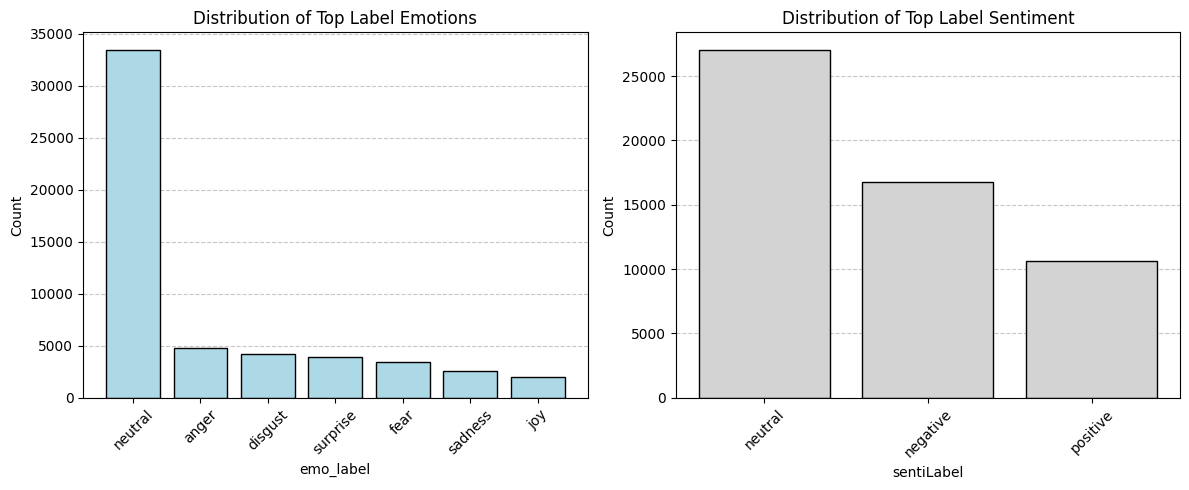

In [20]:
# Plotting
plt.figure(figsize=(12, 5))

# emo_label distribution
plt.subplot(1, 2, 1)
emo_counts = comment_df['emoBERT_top_label'].value_counts()
plt.gca().set_axisbelow(True)  # Grid below bars
plt.bar(emo_counts.index, emo_counts.values, color='#ADD8E6', edgecolor='black')
plt.title('Distribution of Top Label Emotions')
plt.xlabel('emo_label')
plt.ylabel('Count')
plt.xticks(range(len(emo_counts.index)), emo_counts.index, rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# sentiLabel distribution
plt.subplot(1, 2, 2)
senti_counts = comment_df['sentiBERT_top_label'].value_counts()
plt.gca().set_axisbelow(True)  # Grid below bars
plt.bar(senti_counts.index, senti_counts.values, color='#D3D3D3', edgecolor='black')
plt.title('Distribution of Top Label Sentiment')
plt.xlabel('sentiLabel')
plt.ylabel('Count')
plt.xticks(range(len(senti_counts.index)), senti_counts.index, rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

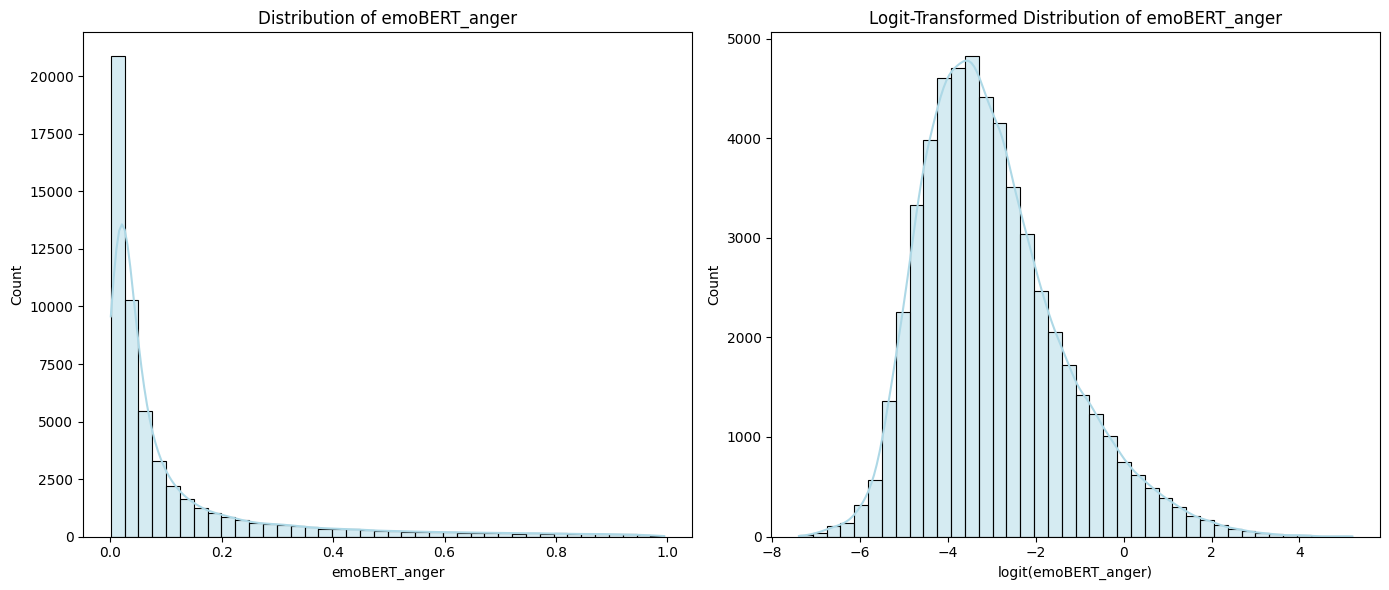

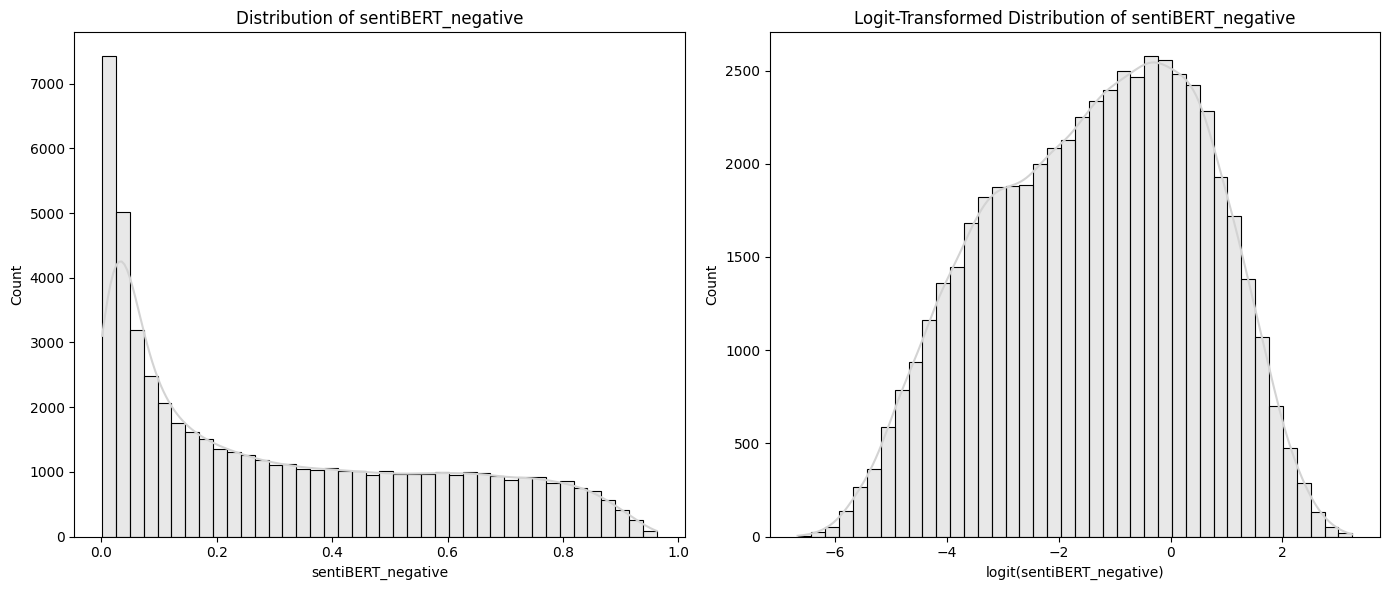

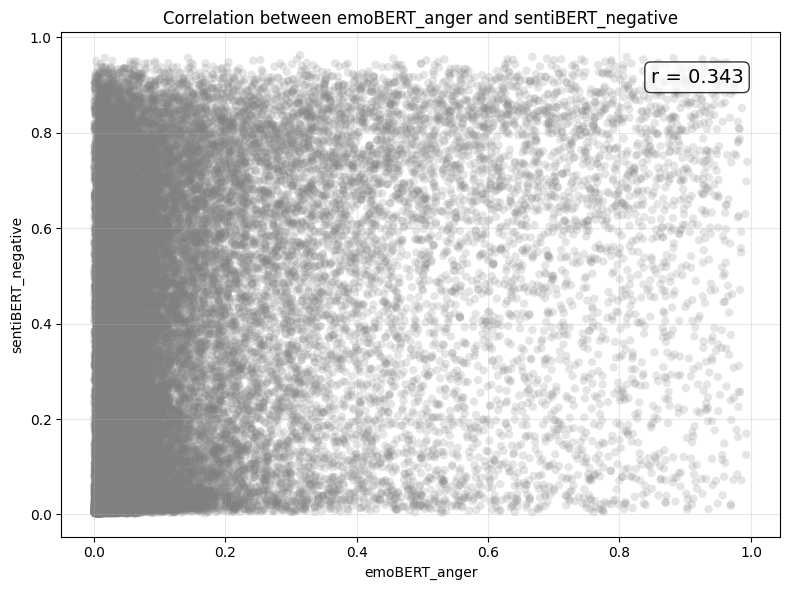

In [21]:
# Using a small epsilon to keep values within (0, 1)
epsilon = 1e-6

# emoBERT_anger: Original and Logit-transformed
plt.figure(figsize=(14, 6))

# emoBERT_anger original distribution
plt.subplot(1, 2, 1)
sns.histplot(comment_df['emoBERT_anger'], bins=40, kde=True, color='#ADD8E6')
plt.title('Distribution of emoBERT_anger')
plt.xlabel('emoBERT_anger')
plt.ylabel('Count')

# emoBERT_anger logit-transformed
plt.subplot(1, 2, 2)
clamped_anger = np.clip(comment_df['emoBERT_anger'], epsilon, 1-epsilon)
sns.histplot(logit(clamped_anger), bins=40, kde=True, color='#ADD8E6')
plt.title('Logit-Transformed Distribution of emoBERT_anger')
plt.xlabel('logit(emoBERT_anger)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# sentiBERT_negative: Original and Logit-transformed
plt.figure(figsize=(14, 6))

# sentiBERT_negative original distribution
plt.subplot(1, 2, 1)
sns.histplot(comment_df['sentiBERT_negative'], bins=40, kde=True, color='#D3D3D3')
plt.title('Distribution of sentiBERT_negative')
plt.xlabel('sentiBERT_negative')
plt.ylabel('Count')

# sentiBERT_negative logit-transformed
plt.subplot(1, 2, 2)
clamped_negative = np.clip(comment_df['sentiBERT_negative'], epsilon, 1-epsilon)
sns.histplot(logit(clamped_negative), bins=40, kde=True, color='#D3D3D3')
plt.title('Logit-Transformed Distribution of sentiBERT_negative')
plt.xlabel('logit(sentiBERT_negative)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()



# Correlation plot between anger and negative variables
plt.figure(figsize=(8, 6))

# Calculate correlation
correlation = comment_df['emoBERT_anger'].corr(comment_df['sentiBERT_negative'])

# Create scatter plot
plt.scatter(comment_df['emoBERT_anger'], comment_df['sentiBERT_negative'],
           alpha=0.2, color='gray', edgecolor='none')

plt.title('Correlation between emoBERT_anger and sentiBERT_negative')
plt.xlabel('emoBERT_anger')
plt.ylabel('sentiBERT_negative')

# Add correlation value inside the plot
plt.text(0.82, 0.9, f'r = {correlation:.3f}',
         transform=plt.gca().transAxes, fontsize=14,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.1.2 Explore Dependent Variable by Subreddit

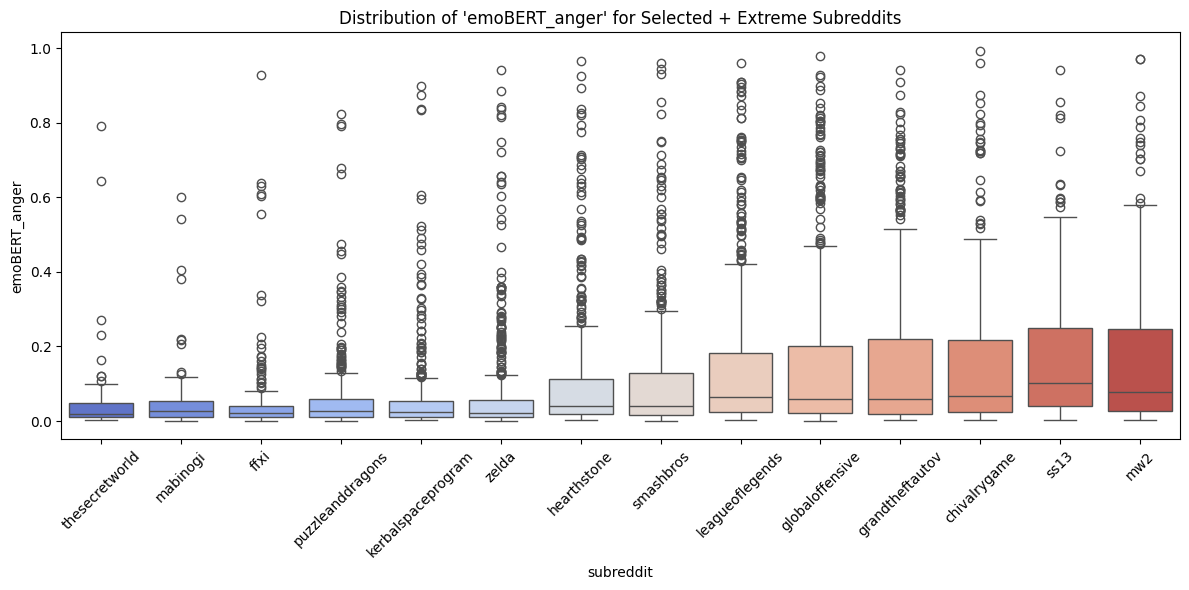

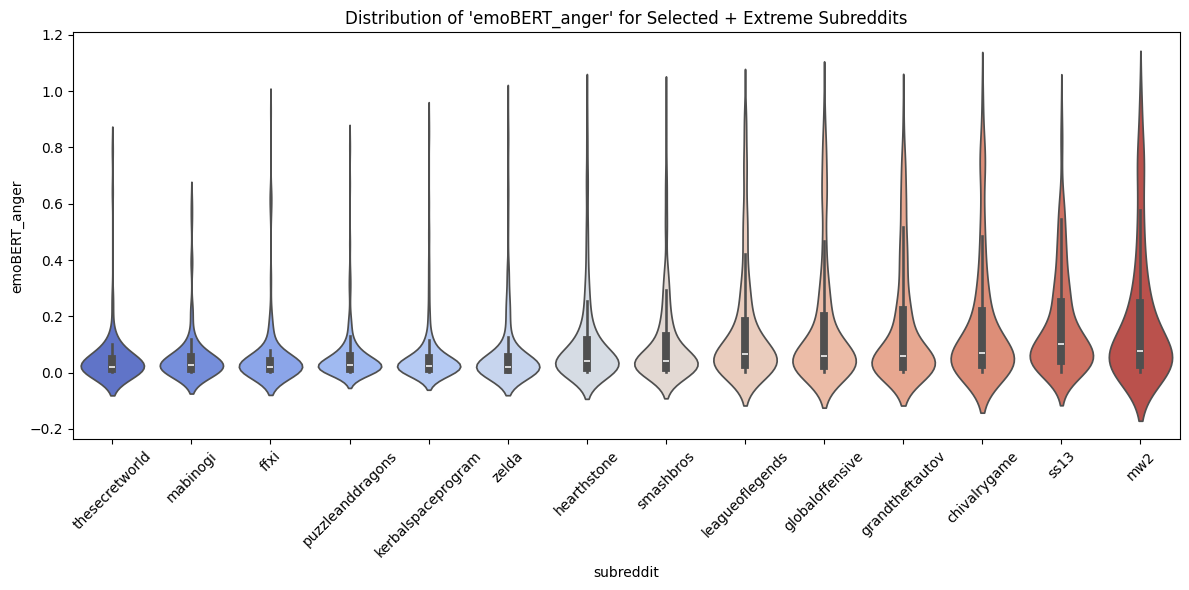

In [22]:
# emoBERT_anger by selected subreddits, ordered by mean

# Selected subreddits -  based on First Part of Project
selected = ['leagueoflegends', 'pokemon', 'zelda', 'overwatch', 'smashbros', 'hearthstone']

# Get summary stats for emoBERT_anger
summary_anger = comment_df.groupby('subreddit', observed=True)['emoBERT_anger'].agg(['mean'])

# Get 5 subreddits with lowest and highest mean anger
lowest_anger = summary_anger.sort_values(by='mean').head(5).index.tolist()
highest_anger = summary_anger.sort_values(by='mean').tail(5).index.tolist()

# Combine with your selected list (removing duplicates)
combined_anger_subreddits = list(set(selected + lowest_anger + highest_anger))

# Filter the dataframe to just those subreddits
subset_anger = comment_df[comment_df['subreddit'].isin(combined_anger_subreddits)]

# Sort subreddit order by mean emoBERT_anger
ordered_anger = subset_anger.groupby('subreddit', observed=True)['emoBERT_anger'].mean().sort_values().index.tolist()

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=subset_anger, x='subreddit', y='emoBERT_anger',
               palette='coolwarm', order=ordered_anger)
plt.title("Distribution of 'emoBERT_anger' for Selected + Extreme Subreddits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=subset_anger, x='subreddit', y='emoBERT_anger',
               inner='box', palette='coolwarm', order=ordered_anger)
plt.title("Distribution of 'emoBERT_anger' for Selected + Extreme Subreddits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.1.3 Explore Dependent Variable by Genre

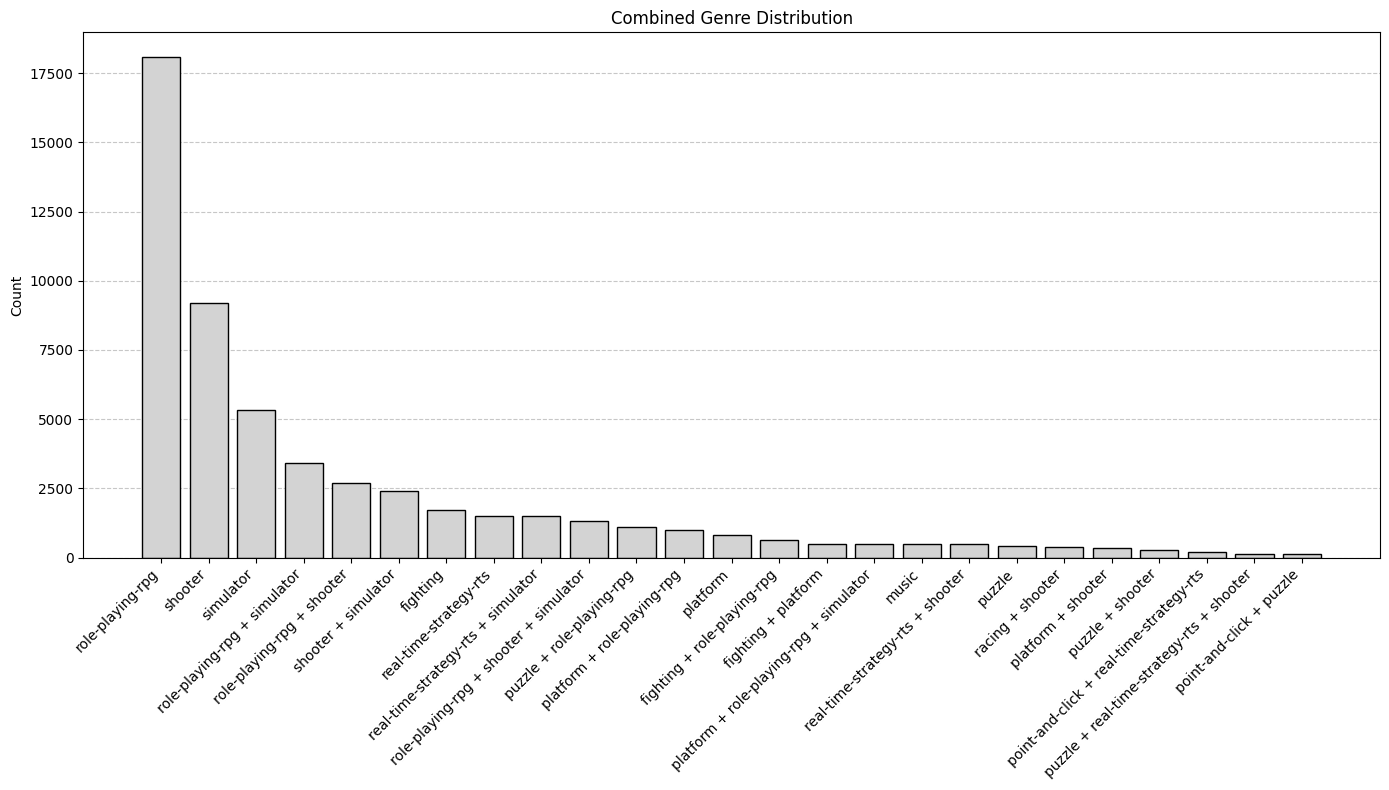

In [23]:
# Show combined_genres

# Count frequency of combined genres
combined_genre_counts = comment_df['combined_genre'].value_counts()

# Plot
plt.figure(figsize=(14, 8))
plt.bar(combined_genre_counts.index, combined_genre_counts.values, color='#D3D3D3', edgecolor='black')
plt.title('Combined Genre Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # rotate x labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

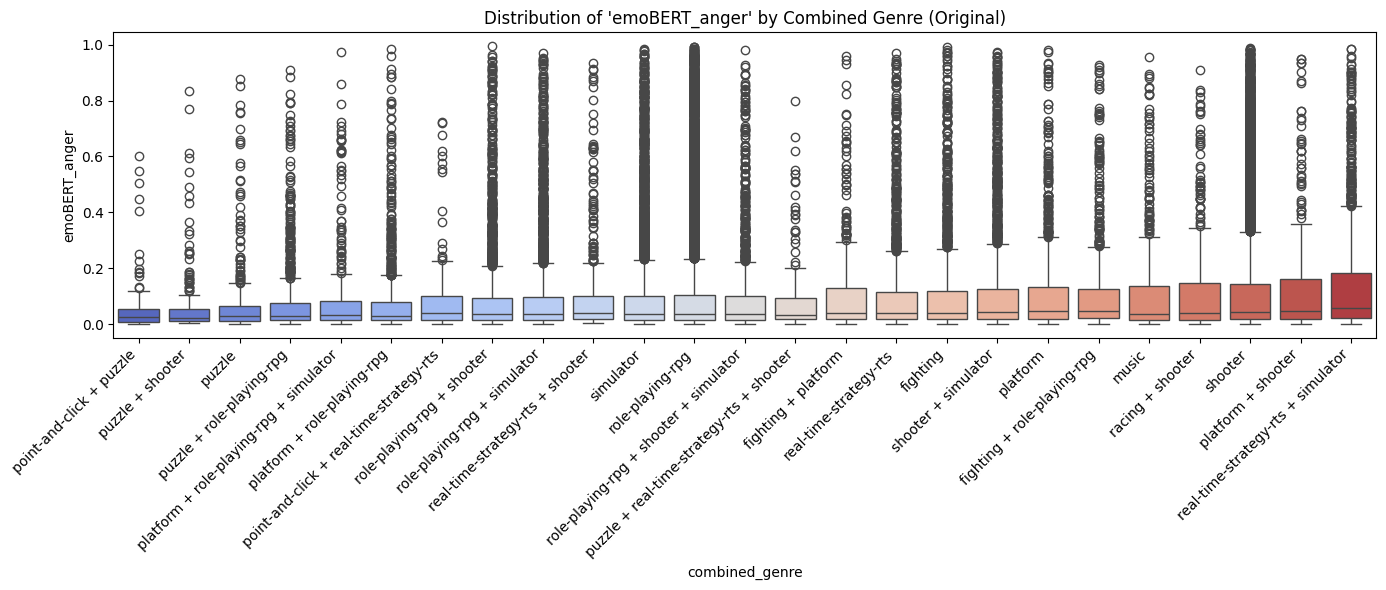

In [24]:
# emoBERT_anger by genres, ordered by mean
ordered_genres_anger = comment_df.groupby('combined_genre')['emoBERT_anger'].mean().sort_values().index.tolist()

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(data=comment_df, x='combined_genre', y='emoBERT_anger',
            palette='coolwarm', order=ordered_genres_anger)
plt.title("Distribution of 'emoBERT_anger' by Combined Genre (Original)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

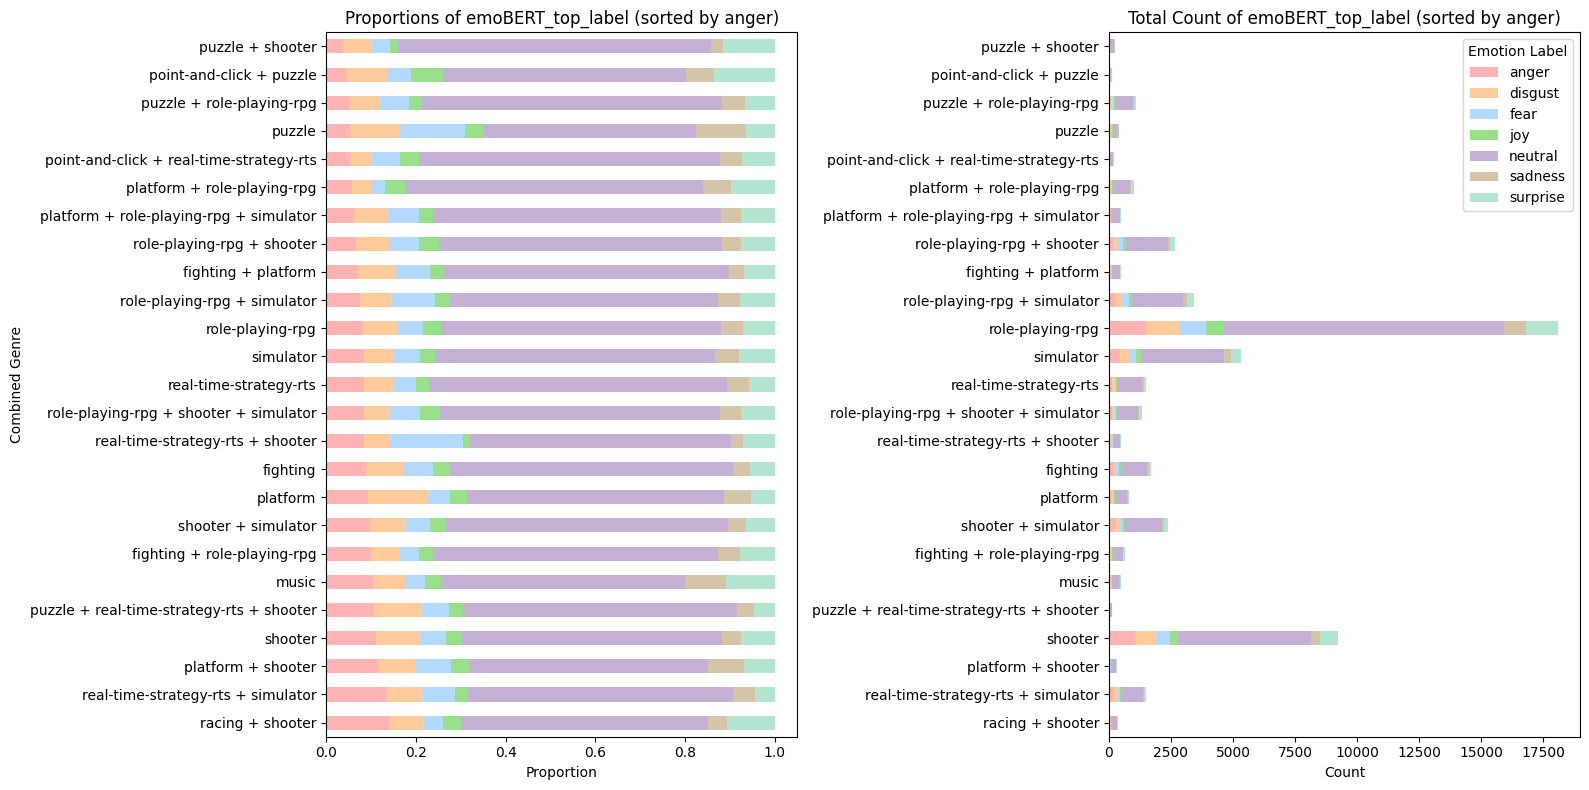

In [25]:
# Proportion of top-labelled outcome class
# Count occurrences of each emoBERT_top_label by combined_genre
df_emo_counts = comment_df.groupby(['combined_genre', 'emoBERT_top_label']).size().unstack(fill_value=0)

# Compute proportions per genre (row-wise normalization)
df_emo_prop = df_emo_counts.div(df_emo_counts.sum(axis=1), axis=0)

# Sort genres by 'anger' proportion descending
sorted_genres = df_emo_prop.sort_values(by='anger', ascending=False).index

# Reorder both dfs accordingly
df_emo_prop_sorted = df_emo_prop.loc[sorted_genres]
df_emo_counts_sorted = df_emo_counts.loc[sorted_genres]

# Define colors
emo_colors = ['#ffb3b3', '#ffcc99', '#b3d9ff', '#98df8a', '#c5b0d5', '#d4c5a9', '#b3e5d1']

plt.figure(figsize=(16, 8))

# Left plot: Proportions
plt.subplot(1, 2, 1)
df_emo_prop_sorted.plot(kind='barh', stacked=True, color=emo_colors, ax=plt.gca())
plt.title("Proportions of emoBERT_top_label (sorted by anger)")
plt.xlabel("Proportion")
plt.ylabel("Combined Genre")
plt.legend().remove()

# Right plot: Absolute counts
plt.subplot(1, 2, 2)
df_emo_counts_sorted.plot(kind='barh', stacked=True, color=emo_colors, ax=plt.gca())
plt.title("Total Count of emoBERT_top_label (sorted by anger)")
plt.xlabel("Count")
plt.ylabel("")
plt.legend(title="Emotion Label", loc='upper right')

plt.tight_layout()
plt.show()

### 4.1.4 Explore Independent Variables

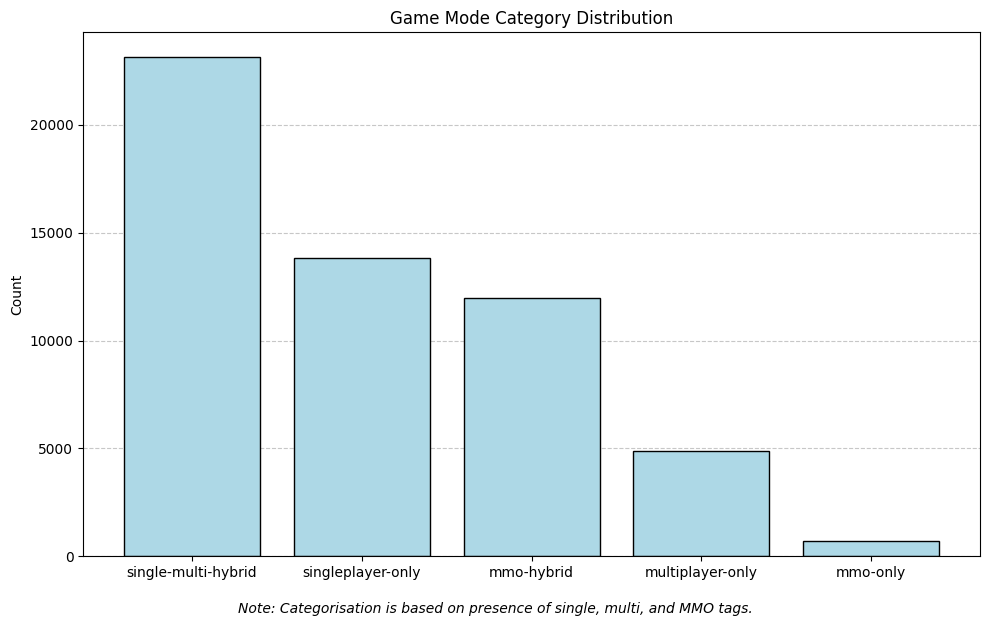

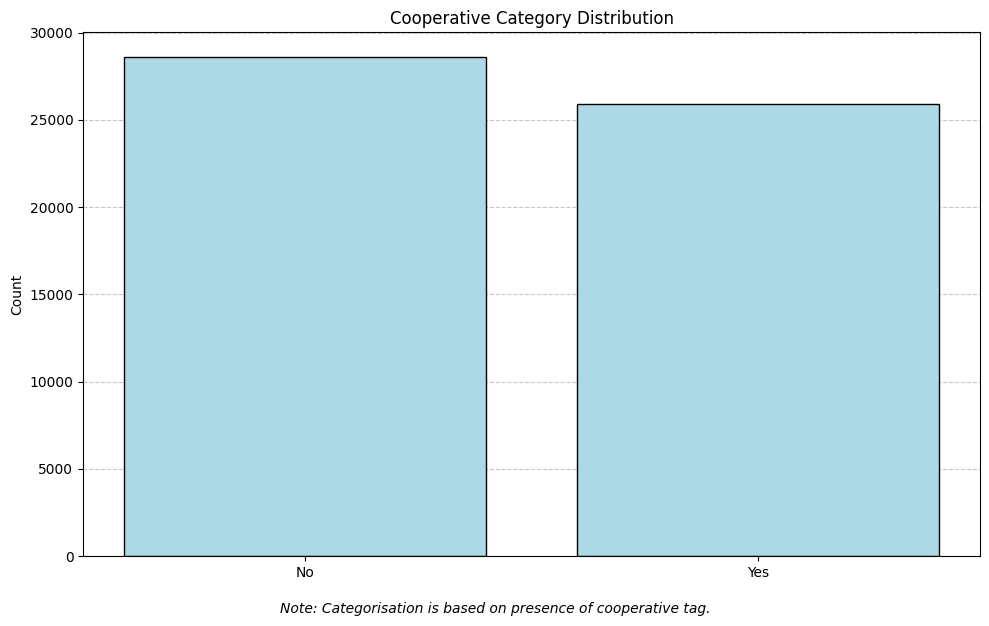

In [26]:
# Plot IVs of main interest: Player Modes and Cooperative
# Count values for mode_category
mode_counts = comment_df['mode_category'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(mode_counts.index, mode_counts.values, color='#ADD8E6', edgecolor='black')
plt.title('Game Mode Category Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
# Add footnote
plt.figtext(0.5, -0.03, 'Note: Categorisation is based on presence of single, multi, and MMO tags.',
            wrap=True, horizontalalignment='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()

# Count values for cooperative category
has_coop = comment_df['has_coop'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(has_coop.index, has_coop.values, color='#ADD8E6', edgecolor='black')
plt.title('Cooperative Category Distribution')
plt.ylabel('Count')
# Custom x-axis labels: map True/False to Yes/No
plt.xticks(ticks=range(len(has_coop.index)), labels=['No', 'Yes'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
# Add footnote
plt.figtext(0.5, -0.03, 'Note: Categorisation is based on presence of cooperative tag.',
            wrap=True, horizontalalignment='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()

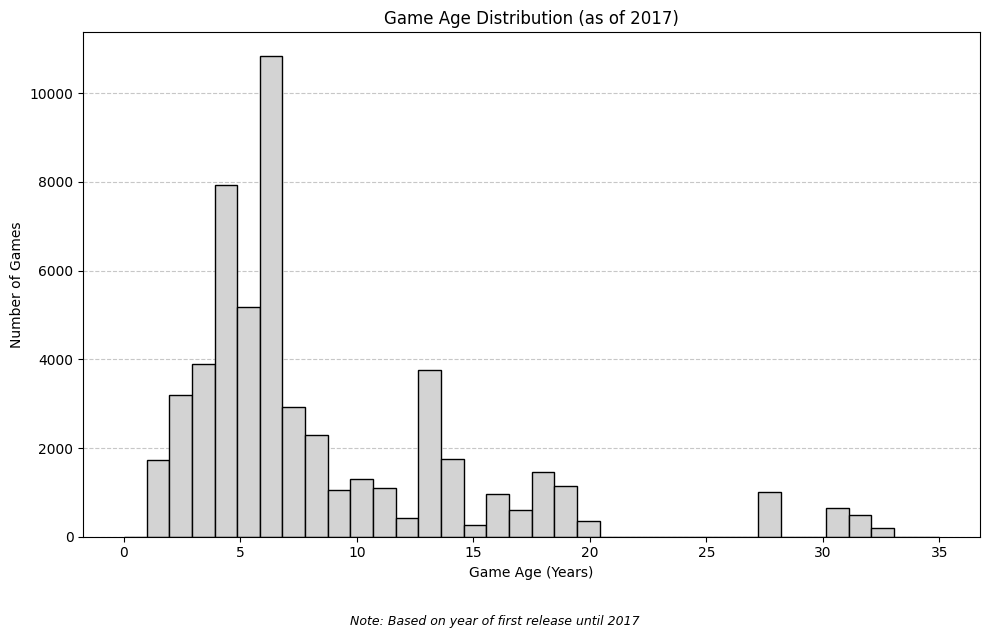

In [27]:
# Plot Game Age Distribution
plt.figure(figsize=(10, 6))
plt.hist(comment_df['game_age'], bins=36, range=(0, 35),
         color='#D3D3D3', edgecolor='black')

plt.title('Game Age Distribution (as of 2017)')
plt.xlabel('Game Age (Years)')
plt.ylabel('Number of Games')

# Set x-axis to show every 5 years for readability
plt.xticks(range(0, 36, 5))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

# Add footnote
plt.figtext(0.5, -0.05, 'Note: Based on year of first release until 2017',
            wrap=True, horizontalalignment='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

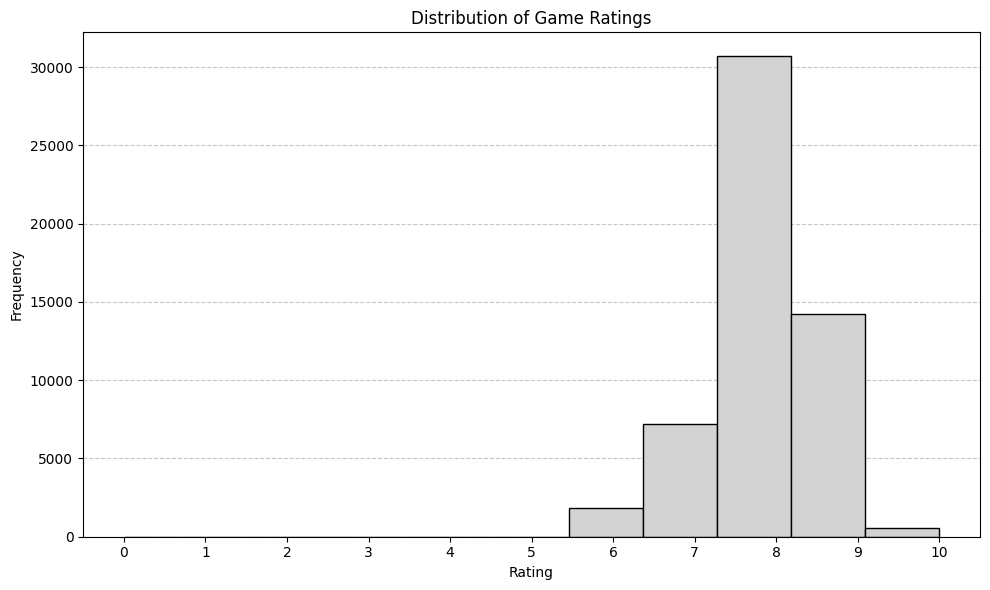

In [28]:
# Plot Rating Distribution
plt.figure(figsize=(10, 6))
plt.hist(comment_df['rating'], bins=11, range=(0, 10),
         color='#D3D3D3', edgecolor='black')

plt.title('Distribution of Game Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

# Set x-axis to show ratings 0-10
plt.xticks(range(0, 11))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

## 4.2 Model Fitting and Visualization of Effects

We use **rpy2** to call R code from within Python, enabling us to leverage R’s statistical packages without leaving the Python environment. In particular, we use lme4, which is a widely used R package for fitting linear and generalized linear mixed-effects models.

Why **lme4**?
Mixed-effects models allow us to account for both fixed effects (e.g., game metadata like mode_rank, has_coop) and random effects (e.g., variation between subreddits, authors, and game genres). This is crucial for handling hierarchical or grouped data structures and properly modeling between- and within-group variance, which standard regression methods can’t capture.

The snippet installs lme4 if missing, loads the package, and fits a mixed-effects model predicting the anger emotion score with relevant fixed and random effects.

In [29]:
comment_df['has_coop'] = comment_df['has_coop'].astype('int32')  # binary category to int32
comment_df.info()

comment_df.to_csv('data_for_models.csv',  index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54505 entries, 0 to 54504
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   author               54505 non-null  category
 1   subreddit            54505 non-null  category
 2   Name                 54505 non-null  category
 3   emoBERT_top_label    54505 non-null  category
 4   emoBERT_top_score    54505 non-null  float64 
 5   emoBERT_anger        54505 non-null  float64 
 6   emoBERT_disgust      54505 non-null  float64 
 7   emoBERT_fear         54505 non-null  float64 
 8   emoBERT_joy          54505 non-null  float64 
 9   emoBERT_neutral      54505 non-null  float64 
 10  emoBERT_sadness      54505 non-null  float64 
 11  emoBERT_surprise     54505 non-null  float64 
 12  sentiBERT_top_label  54505 non-null  category
 13  sentiBERT_top_score  54505 non-null  float64 
 14  sentiBERT_negative   54505 non-null  float64 
 15  sentiBERT_neutral  

In [30]:
!pip install rpy2 --quiet

In [31]:
%load_ext rpy2.ipython

In [32]:
%%R -i comment_df -o model_results,predictions,pred_comparison

if (!require(lme4, quietly = TRUE)) {
  install.packages("lme4", repos = "https://cran.r-project.org")
}

library(lme4)

# Fit the model
model <- lmer(
  emoBERT_anger ~ mode_rank * has_coop + game_age + rating +
  (1 | combined_genre) + (1 | subreddit) + (1 | author),
  data = comment_df
)

# Model summary
print(summary(model))

# Extract what we need for Python
fixed_coefs <- fixef(model)
vcov_matrix <- vcov(model)

# Create prediction grid
pred_grid <- expand.grid(mode_rank = 1:5, has_coop = c(0, 1))
pred_grid$game_age <- mean(comment_df$game_age, na.rm = TRUE)
pred_grid$rating <- mean(comment_df$rating, na.rm = TRUE)

# Calculate predictions and CIs
X <- model.matrix(~ mode_rank * has_coop + game_age + rating, data = pred_grid)
pred_grid$predicted <- as.vector(X %*% fixed_coefs)
pred_grid$se <- sqrt(diag(X %*% vcov_matrix %*% t(X)))
pred_grid$conf_low <- pred_grid$predicted - 1.96 * pred_grid$se
pred_grid$conf_high <- pred_grid$predicted + 1.96 * pred_grid$se

# Generate predictions for actual vs predicted
comment_df$predicted <- predict(model)
comment_df$predicted_fixed <- predict(model, re.form = NA)

# Prepare data for Python
model_results <- pred_grid
predictions <- comment_df[, c("emoBERT_anger", "predicted", "predicted_fixed")]

# Create comparison data
pred_comparison <- data.frame(
  actual = comment_df$emoBERT_anger,
  pred_with_random = comment_df$predicted,
  pred_fixed_only = comment_df$predicted_fixed
)

# Calculate R-squared values
r_squared_with_re <- cor(pred_comparison$actual, pred_comparison$pred_with_random, use = "complete.obs")^2
r_squared_fixed <- cor(pred_comparison$actual, pred_comparison$pred_fixed_only, use = "complete.obs")^2

cat("With Random Effects - R-squared:", round(r_squared_with_re, 3), "\n")
cat("Fixed Effects Only - R-squared:", round(r_squared_fixed, 3), "\n")

Linear mixed model fit by REML ['lmerMod']
Formula: emoBERT_anger ~ mode_rank * has_coop + game_age + rating + (1 |  
    combined_genre) + (1 | subreddit) + (1 | author)
   Data: comment_df

REML criterion at convergence: -37961.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.1711 -0.5120 -0.3469  0.0172  5.1651 

Random effects:
 Groups         Name        Variance  Std.Dev.
 author         (Intercept) 1.293e-03 0.035958
 subreddit      (Intercept) 5.910e-04 0.024310
 combined_genre (Intercept) 9.299e-05 0.009643
 Residual                   2.778e-02 0.166675
Number of obs: 54505, groups:  
author, 40693; subreddit, 144; combined_genre, 25

Fixed effects:
                     Estimate Std. Error t value
(Intercept)         0.0588789  0.0290079   2.030
mode_rank           0.0039047  0.0028691   1.361
has_coop            0.0361690  0.0128618   2.812
game_age            0.0001036  0.0003707   0.279
rating              0.0043304  0.0034516   1.255
mode_rank:has_coop -0.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’

trying URL 'https://cran.r-project.org/src/contrib/rbibutils_2.3.tar.gz'
trying URL 'https://cran.r-project.org/src/contrib/Rdpack_2.6.4.tar.gz'
trying URL 'https://cran.r-project.org/src/contrib/minqa_1.2.8.tar.gz'
trying URL 'https://cran.r-project.org/src/contrib/nloptr_2.2.1.tar.gz'
trying URL 'https://cran.r-project.org/src/contrib/reformulas_0.4.1.tar.gz'
trying URL 'https://cran.r-project.org/src/contrib/RcppEigen_0.3.4.0.2.tar.gz'
trying URL 'https://cran.r-project.org/src/contrib/lme4_1.1-37.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp8BSsdM/downloaded_packages’
Loading required package: Matrix


The linear mixed-effects model shows that the presence of cooperative gameplay (has_coop) is significantly associated with a higher anger probability score, while the interaction between mode_rank and has_coop is negative and significant, suggesting that the effect of game mode rank on anger depends on whether the game includes cooperative play.

Random effects for author, subreddit, and combined_genre capture some variability, with the largest variance at the author level, indicating individual differences in anger expression.

Fixed effects alone explain a small portion of variance (R² ≈ 0.003), but including random effects improves the explained variance (R² ≈ 0.172), highlighting the importance of accounting for hierarchical structure in the data.

Other predictors like game_age and rating show no significant effects here.

Back to Python:

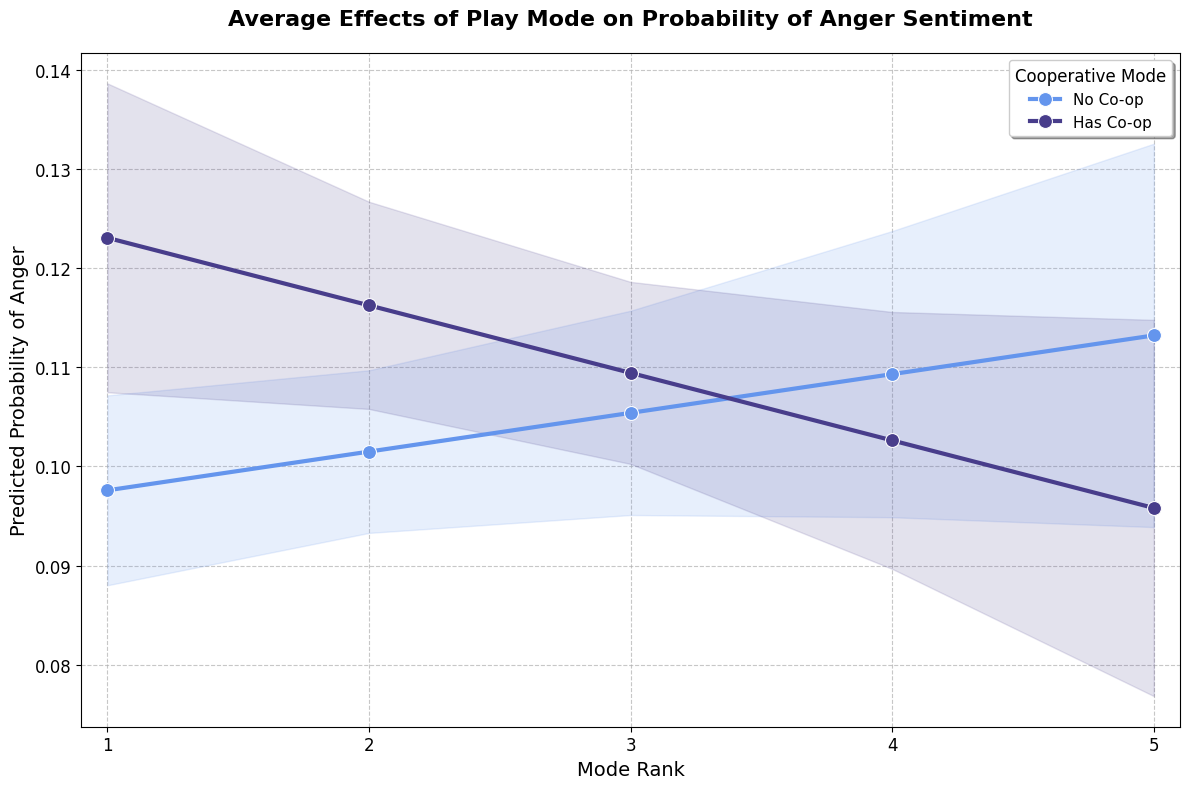

In [33]:
# Data
model_df = pd.DataFrame(model_results)
pred_df = pd.DataFrame(predictions)

# Plot: Interaction Effects
fig, ax = plt.subplots(figsize=(12, 8))

# Create the line plot
sns.lineplot(data=model_df, x='mode_rank', y='predicted', hue='has_coop',
             marker='o', markersize=10, linewidth=3,
             palette=['#6495ED', '#483D8B'])

# Add confidence intervals
for coop_val, color in zip([0, 1], ['#6495ED', '#483D8B']):
    subset = model_df[model_df['has_coop'] == coop_val]
    ax.fill_between(subset['mode_rank'], subset['conf_low'], subset['conf_high'],
                    alpha=0.15, color=color)

# Styling
ax.set_xlabel('Mode Rank', fontsize=14)
ax.set_ylabel('Predicted Probability of Anger', fontsize=14)
ax.set_title('Average Effects of Play Mode on Probability of Anger Sentiment',
             fontsize=16, fontweight='bold', pad=20)

# Customize axes
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlim(0.9, 5.1)
ax.tick_params(axis='both', which='major', labelsize=12)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7, linewidth=0.8)
ax.set_axisbelow(True)

# Legend
handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(handles, ['No Co-op', 'Has Co-op'],
                   title='Cooperative Mode',
                   title_fontsize=12, fontsize=11,
                   loc='upper right', frameon=True,
                   fancybox=True, shadow=True)
#legend.get_title().set_fontweight('bold')

# Add subtle background color
#ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.show()

When plotting the predicted anger probabilities for multiplayer games with and without cooperative play, we observe that at mode rank 1 (single-player), the confidence intervals do not overlap, indicating a statistically meaningful difference in anger levels between these groups. However, for higher mode ranks (2 and above), the confidence intervals overlap, suggesting that the differences in anger probabilities between cooperative and non-cooperative games become less distinct and are not statistically significant at those levels. This pattern highlights that the cooperative effect on anger is most pronounced in single-player or lower mode ranks, but diminishes as the mode complexity increases.


## 4.3 Model Evaluation

Back to Python

Model Fit Statistics:
R-squared: 0.172
RMSE: 0.163
MAE: 0.106


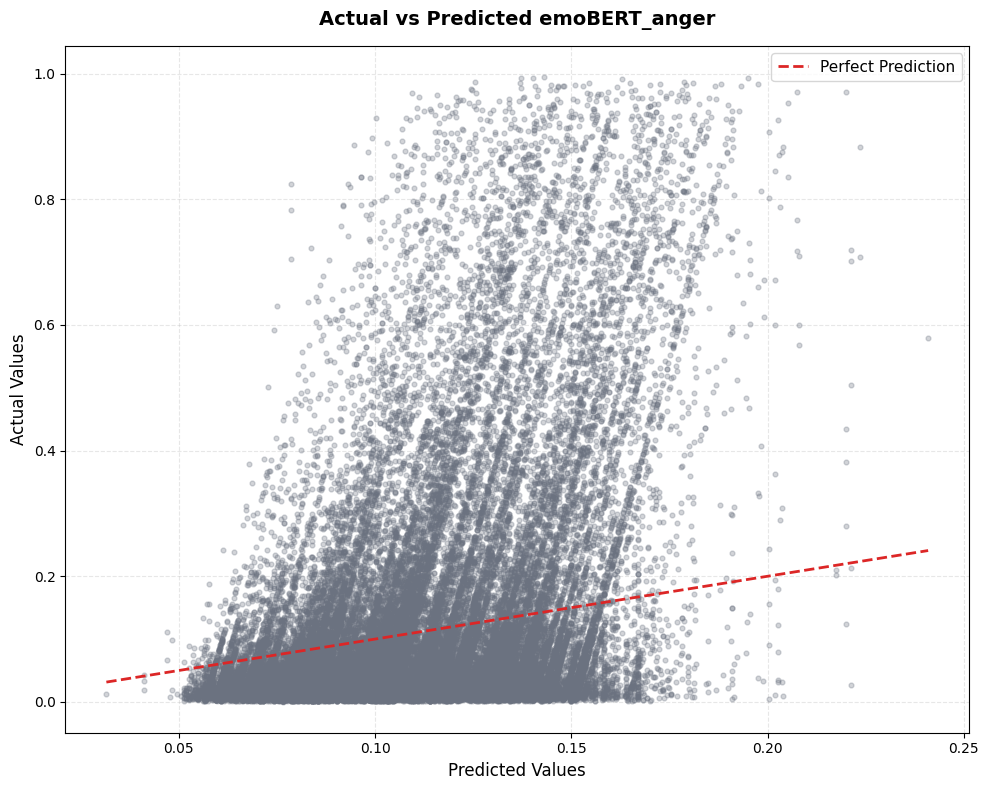

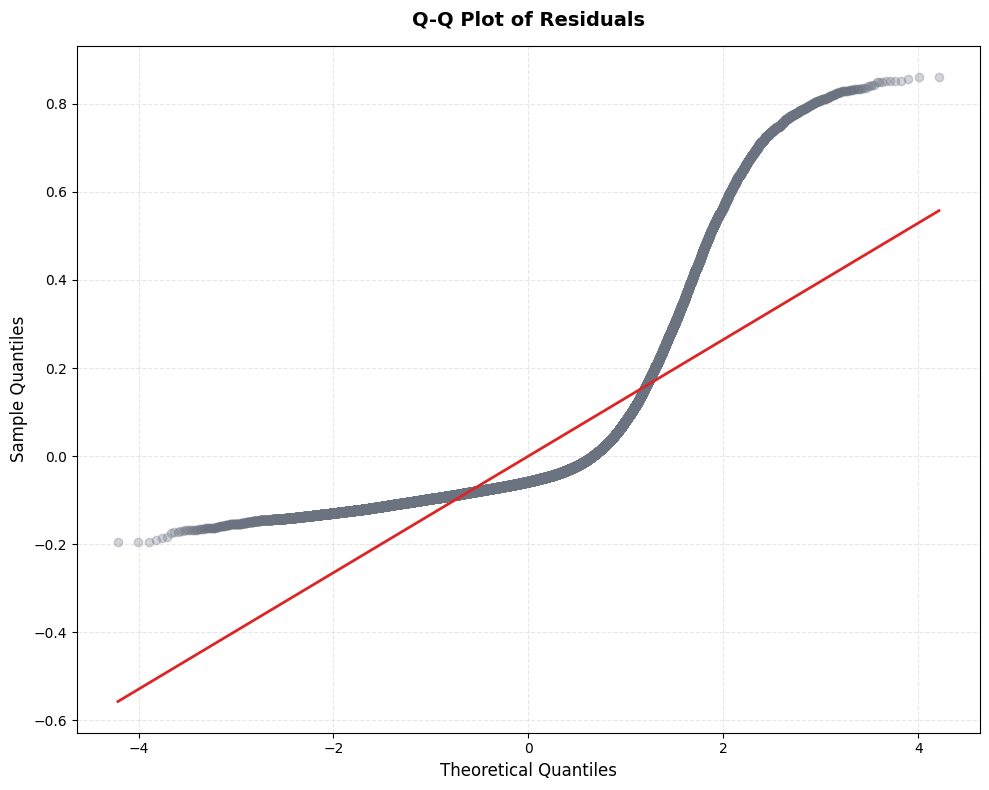

In [34]:
# Fit Statistics
actual = pred_df['emoBERT_anger']
predicted = pred_df['predicted']
r2 = np.corrcoef(actual, predicted)[0, 1]**2
rmse = np.sqrt(np.mean((actual - predicted)**2))
mae = np.mean(np.abs(actual - predicted))

print(f"Model Fit Statistics:")
print(f"R-squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

# Residual/Predicted Values Visualizations
# Colors
gray = '#6B7280'
red = '#DC2626'

# Plot: Actual vs Predicted
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(pred_df['predicted'], pred_df['emoBERT_anger'],
           alpha=0.3, s=12, color=gray)
ax.plot([pred_df['predicted'].min(), pred_df['predicted'].max()],
        [pred_df['predicted'].min(), pred_df['predicted'].max()],
        '--', linewidth=2, color=red, label='Perfect Prediction')

ax.set_xlabel('Predicted Values', fontsize=12)
ax.set_ylabel('Actual Values', fontsize=12)
ax.set_title('Actual vs Predicted emoBERT_anger', fontsize=14, fontweight='bold', pad=15)


ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Plot: Q-Q Plot
fig, ax = plt.subplots(figsize=(10, 8))
residuals = pred_df['emoBERT_anger'] - pred_df['predicted']

# Create Q-Q plot (remove alpha parameter - it's not supported)
stats.probplot(residuals, dist="norm", plot=ax)

# Style the Q-Q plot
ax.get_lines()[0].set_color(gray)
ax.get_lines()[0].set_linewidth(2)
ax.get_lines()[0].set_alpha(0.3)  # Set alpha for the data points line
ax.get_lines()[1].set_color(red)
ax.get_lines()[1].set_linewidth(2)

ax.set_title('Q-Q Plot of Residuals', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Theoretical Quantiles', fontsize=12)
ax.set_ylabel('Sample Quantiles', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

Model diagnostics indicate that the residuals are right-skewed, as confirmed by the QQ plot which shows a pronounced S-curve pattern. This suggests deviations from the normality assumption of residuals in the linear mixed-effects model. The relatively low R-squared values—both with and without random effects—imply that key predictors explaining variation in anger probability are likely missing from the model, highlighting the complexity of sentiment in subreddit gaming posts. Other assumptions such as homoscedasticity and independence of residuals should also be checked, but the observed skewness and model fit already point to model limitations that might be addressed by including additional explanatory variables or exploring alternative model specifications.

# Part V: Discussion and Conclusion

This analysis explored how game metadata—particularly game mode (e.g., multiplayer/cooperative play), game age, and user rating—relate to anger probability scores derived from an emotion classifier (emoBERT) applied to Reddit gaming comments. Guided by the General Learning Model (GLM) and prior findings (Greitemeyer & Mügge, 2014; Anderson et al., 2010), we focused on two main research questions:

- Does increased team play (higher multiplayer involvement) correlate with elevated anger expression in online gaming communities?
- Does cooperative gameplay reduce anger expression, particularly in genres or subreddits associated with violent or competitive content?

Our first hypothesis predicted that games involving more players or multiplayer modes would be associated with higher anger expression, reflecting frustration and conflict common in team play scenarios. The second hypothesis posited that cooperative gameplay would mitigate anger expression by promoting prosocial interaction, especially in contexts of violent or competitive games.

Using a linear mixed-effects model with random intercepts for author, subreddit, and combined genre to account for nested data and unobserved heterogeneity, we modeled fixed effects for multiplayer rank, cooperative mode, game age, and rating. Results partially supported the hypotheses: higher multiplayer ranking was generally associated with increased anger, consistent with the first hypothesis. However, the interaction between multiplayer rank and cooperative mode revealed that cooperative play reduced anger expression at lower multiplayer levels—suggesting that cooperation may buffer anger in smaller team settings. At higher multiplayer levels, this mitigating effect diminished, indicating more complex social dynamics possibly influenced by other unmeasured factors.

Several limitations temper these conclusions. Measurement errors in the IGDB metadata—for example, underreported cooperative features in some games—likely attenuated effect estimates. Similarly, emoBERT’s classification accuracy and the absence of contextual variables such as post timing, community feedback (upvotes/downvotes), and distinctions between online and offline play constrain explanatory power. The residual distribution’s right skew and low fixed-effects R-squared indicate that key predictors of anger remain unmodeled.

Furthermore, the Reddit gaming community represents a selective and emotionally expressive population, limiting the generalizability of findings. The comment-level approach, without user or game-level aggregation, may inflate significance due to non-independence of observations. Crucially, the lack of data distinguishing online versus offline cooperative play restricts interpretation of the cooperation effect, as these contexts likely differ substantially in social dynamics.

**In conclusion**, our findings offer preliminary evidence supporting the GLM’s framework: cooperative gameplay can attenuate anger expression in online gaming discourse, especially in less complex multiplayer contexts. The data also confirm that increased multiplayer involvement tends to raise anger expression, aligning with expectations about team-based frustrations. Future research should refine metadata quality, incorporate richer contextual variables, and examine these dynamics across more representative gaming populations and interaction types. Despite limitations, this study demonstrates the value of integrating emotion classification with detailed game metadata to illuminate the social-emotional effects of video game play in real-world online communities.